### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [5]:
## Fix passanger column typo
data.rename(columns={'passanger': 'passenger'}, inplace=True)

2. Investigate the dataset for missing or problematic data.

In [6]:
data.isnull().sum()

destination                 0
passenger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
## completely dropping column "car" since 12576 out of 12684 rows are missing values, won't be useful for the analysis
cleaned_data = data.drop(columns=["car"])

## dropping rows with missing values in columns "Bar","CoffeeHouse","CarryAway","RestaurantLessThan20","Restaurant20To50" since they only have inmaterial number of rows missing the values
cleaned_data.dropna(subset=["Bar","CoffeeHouse","CarryAway","RestaurantLessThan20","Restaurant20To50"], inplace=True)

In [8]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12079 non-null  object
 1   passenger             12079 non-null  object
 2   weather               12079 non-null  object
 3   temperature           12079 non-null  int64 
 4   time                  12079 non-null  object
 5   coupon                12079 non-null  object
 6   expiration            12079 non-null  object
 7   gender                12079 non-null  object
 8   age                   12079 non-null  object
 9   maritalStatus         12079 non-null  object
 10  has_children          12079 non-null  int64 
 11  education             12079 non-null  object
 12  occupation            12079 non-null  object
 13  income                12079 non-null  object
 14  Bar                   12079 non-null  object
 15  CoffeeHouse           12079 non-null  ob

In [9]:
cleaned_data.isnull().sum()

destination             0
passenger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [10]:
cleaned_data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12079.000000,12079.000000,12079.0,12079.000000,12079.000000,12079.000000,12079.000000,12079.000000
mean,63.334713,0.408478,1.0,0.561222,0.119381,0.215167,0.784833,0.569335
std,19.133246,0.491573,0.0,0.496258,0.324249,0.410955,0.410955,0.495190
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [30]:
categorical_cols = cleaned_data.select_dtypes(include=["object"]).columns
#categorical_cols_plus = categorical_cols.tolist() + ["Y"]
#df_categorical = cleaned_data[categorical_cols_plus]
#df_categorical.info()

In [31]:
numeric_cols = cleaned_data.select_dtypes(include=[np.number]).columns
df_numeric = cleaned_data[numeric_cols]
df_numeric.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12079 entries, 22 to 12683
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   temperature        12079 non-null  int64
 1   has_children       12079 non-null  int64
 2   toCoupon_GEQ5min   12079 non-null  int64
 3   toCoupon_GEQ15min  12079 non-null  int64
 4   toCoupon_GEQ25min  12079 non-null  int64
 5   direction_same     12079 non-null  int64
 6   direction_opp      12079 non-null  int64
 7   Y                  12079 non-null  int64
dtypes: int64(8)
memory usage: 849.3 KB


4. What proportion of the total observations chose to accept the coupon?



In [60]:
cleaned_data["Y"].mean()

np.float64(0.5693352098683666)

**Oberservation: Close to 57% of total observations accepted the coupons**

5. Use a bar plot to visualize the `coupon` column.

Text(0, 0.5, 'Count')

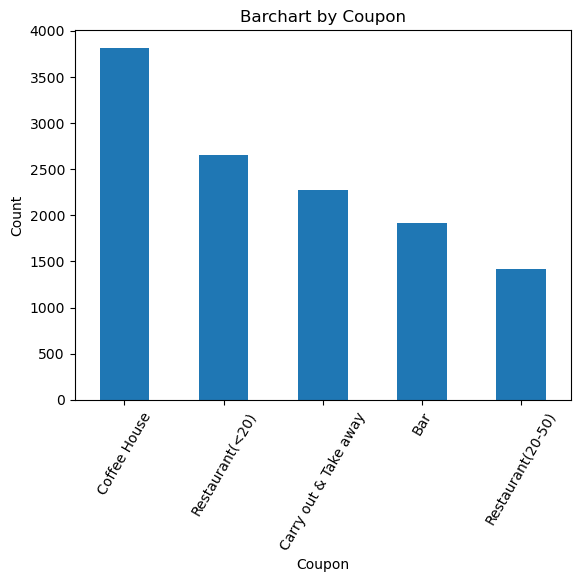

In [12]:
plt.title("Barchart by Coupon")
cleaned_data["coupon"].value_counts().plot(kind="bar")
plt.xticks(rotation=60)
plt.xlabel("Coupon")
plt.ylabel("Count")

6. Use a histogram to visualize the temperature column.

Text(0, 0.5, 'Count')

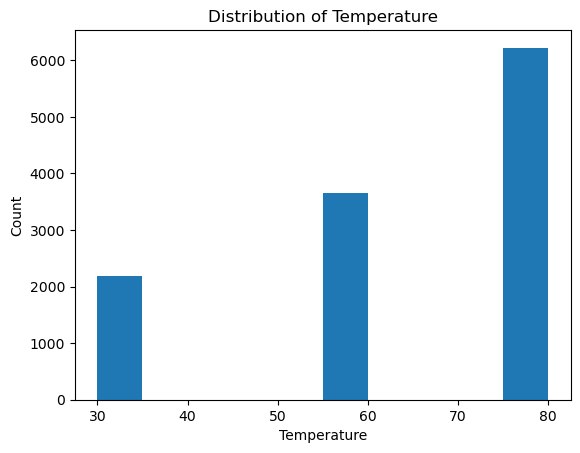

In [13]:
plt.title("Distribution of Temperature")
plt.hist(cleaned_data["temperature"])
plt.xlabel("Temperature")
plt.ylabel("Count")

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [61]:
df_bar_coupon = cleaned_data[cleaned_data["coupon"] == "Bar"].copy()
df_bar_coupon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1913 entries, 24 to 12682
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           1913 non-null   object
 1   passenger             1913 non-null   object
 2   weather               1913 non-null   object
 3   temperature           1913 non-null   int64 
 4   time                  1913 non-null   object
 5   coupon                1913 non-null   object
 6   expiration            1913 non-null   object
 7   gender                1913 non-null   object
 8   age                   1913 non-null   object
 9   maritalStatus         1913 non-null   object
 10  has_children          1913 non-null   int64 
 11  education             1913 non-null   object
 12  occupation            1913 non-null   object
 13  income                1913 non-null   object
 14  Bar                   1913 non-null   object
 15  CoffeeHouse           1913 non-null   obj

2. What proportion of bar coupons were accepted?


In [ ]:
df_bar_coupon["Y"].mean()

## About 41% of survey participants who received the "Bar" coupon accepted it

np.float64(0.41191845269210664)

**Oberservation: About 41% of bar coupons were accepted, which is lower than the overall acceptance rate**

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [16]:
## Check current bar visits column

df_bar_coupon['Bar'].value_counts()
#df_bar_coupon['Bar'].unique()

Bar
never    788
less1    553
1~3      379
4~8      147
gt8       46
Name: count, dtype: int64

In [17]:
## Per the instruction, bucket the bar visits into two categories: 0-3 times and more than 3 times\
df_bar_coupon['bar_visits_gt3'] = df_bar_coupon['Bar'].replace({'never':'0-3', 'less1': '0-3', '1~3': '0-3', 'gt8': 'gt3', '4~8': 'gt3'})
df_bar_coupon['bar_visits_gt3'].value_counts()

bar_visits_gt3
0-3    1720
gt3     193
Name: count, dtype: int64

In [57]:
## Calculate the acceptance rate for each bar visit category
df_bar_coupon.groupby("bar_visits_gt3")["Y"].mean()

bar_visits_gt3
0-3    0.372674
gt3    0.761658
Name: Y, dtype: float64

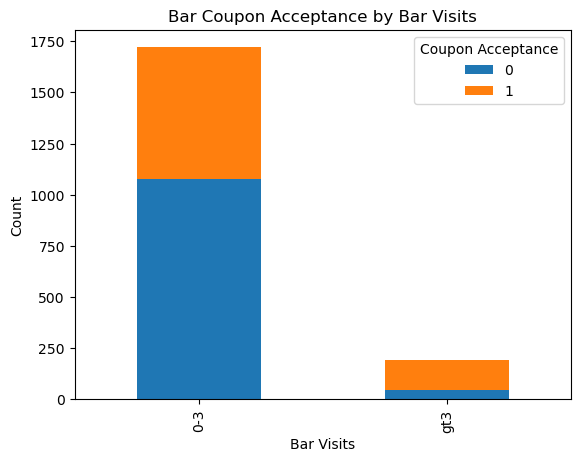

In [40]:
## Bar chart to visualize the acceptance rate by bar visit category
df_bar_coupon.groupby(['bar_visits_gt3', 'Y']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Bar Coupon Acceptance by Bar Visits")
plt.xlabel("Bar Visits")
plt.ylabel("Count")
plt.legend(title="Coupon Acceptance", loc="upper right")
plt.show()

**Oberservation: The majority of the survey participates who received the bar coupon visit bar <=3 times a month; people who visit bars greater than 3 times monthly are way more likely to accept the bar coupon compared to those who vist 3 times or less - 76% (over 3/4) vs. 37% (slightly above 1/3)**

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [20]:
## Understand age column to filter
df_bar_coupon['age'].value_counts().sort_index()

age
21         397
26         368
31         324
36         196
41         171
46         103
50plus     273
below21     81
Name: count, dtype: int64

In [21]:
## Bucket by age >25 and have more than 1 bar visti per month
df_bar_coupon['barvisits_gt1_age_gt25'] = "No"
df_bar_coupon.loc[
    (~df_bar_coupon['Bar'].isin(['never', 'less1'])) & 
    (~df_bar_coupon['age'].isin(['below21', '21'])), 
    'barvisits_gt1_age_gt25'
] = "Yes"

df_bar_coupon['barvisits_gt1_age_gt25'].value_counts()

barvisits_gt1_age_gt25
No     1510
Yes     403
Name: count, dtype: int64

In [56]:
## Calculate the acceptance rate by bar visit >1 and age >25
df_bar_coupon.groupby("barvisits_gt1_age_gt25")["Y"].mean()

barvisits_gt1_age_gt25
No     0.337748
Yes    0.689826
Name: Y, dtype: float64

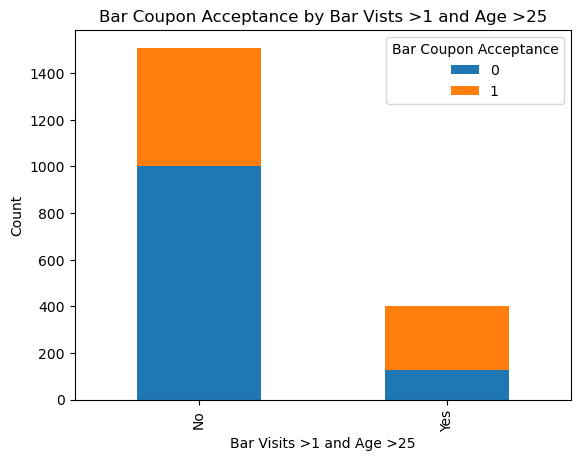

In [39]:
## Bar chart to visualize the acceptance rate by bar visit >1 and age >25
df_bar_coupon.groupby(['barvisits_gt1_age_gt25', 'Y']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Bar Coupon Acceptance by Bar Vists >1 and Age >25")
plt.xlabel("Bar Visits >1 and Age >25")
plt.ylabel("Count")
plt.legend(title="Bar Coupon Acceptance", loc="upper right")
plt.show()

**Oberservation: The majority of the survey participates who received the bar coupon are either less than 26-year-old or have less than 1 bar visit monthly; people in the targeted profile (have more than 1 bar visits montly and older than 25) do have a higher acceptance rate of the bar coupon than those not in the targeted profile - 69% vs. 34%, almost double the chance to accept the coupon**

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [24]:
df_bar_coupon["occupation"].value_counts()

occupation
Unemployed                                   292
Student                                      237
Computer & Mathematical                      225
Sales & Related                              175
Education&Training&Library                   125
Management                                   108
Office & Administrative Support              101
Arts Design Entertainment Sports & Media      88
Business & Financial                          82
Retired                                       71
Healthcare Support                            44
Food Preparation & Serving Related            43
Community & Social Services                   40
Healthcare Practitioners & Technical          36
Transportation & Material Moving              35
Legal                                         34
Protective Service                            27
Architecture & Engineering                    27
Personal Care & Service                       25
Construction & Extraction                     24
Life Phys

In [25]:
df_bar_coupon["passenger"].value_counts()

passenger
Alone        1141
Friend(s)     318
Partner       260
Kid(s)        194
Name: count, dtype: int64

In [26]:
## Define bar_group5 as drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry
df_bar_coupon["bar_group5"] = "No"
df_bar_coupon.loc[
    (~df_bar_coupon['Bar'].isin(['never', 'less1'])) & 
    (df_bar_coupon['passenger'] != "Kid(s)") &
    (df_bar_coupon['occupation'] != "Farming Fishing & Forestry"), 
    'bar_group5'] = "Yes"

In [55]:
## Calculate the acceptance rate by bar_group5
df_bar_coupon.groupby("bar_group5")["Y"].mean()

bar_group5
No     0.297903
Yes    0.709434
Name: Y, dtype: float64

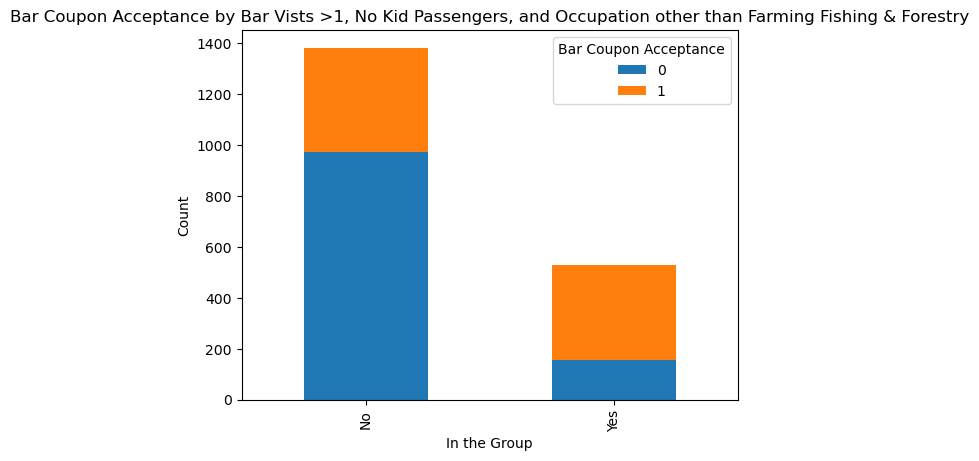

In [38]:
## Bar chart to visualize the acceptance rate by bar_group5
df_bar_coupon.groupby(['bar_group5', 'Y']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Bar Coupon Acceptance by Bar Vists >1, No Kid Passengers, and Occupation other than Farming Fishing & Forestry")
plt.xlabel("In the Group")
plt.ylabel("Count")
plt.legend(title="Bar Coupon Acceptance", loc="upper right")
plt.show()

**Oberservation: People in the targeted profile are less than half of those who are not; people in the targeted profile (have more than 1 bar visits montly, have no kids as passenger and not in Farming Fishing & Forestry occupation) do have a higher acceptance rate of the bar coupon than those not in the targeted profile - 71% vs. 30%, almost exact opposite**

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [34]:
df_bar_coupon["maritalStatus"].value_counts()

maritalStatus
Married partner      833
Single               638
Unmarried partner    352
Divorced              73
Widowed               17
Name: count, dtype: int64

In [35]:
df_bar_coupon["income"].value_counts()

income
$25000 - $37499     300
$100000 or More     282
$12500 - $24999     271
$50000 - $62499     249
$37500 - $49999     247
Less than $12500    159
$75000 - $87499     143
$87500 - $99999     133
$62500 - $74999     129
Name: count, dtype: int64

In [36]:
df_bar_coupon["RestaurantLessThan20"].value_counts()

RestaurantLessThan20
1~3      839
4~8      548
less1    312
gt8      186
never     28
Name: count, dtype: int64

In [64]:
## Flag the participants who meet the above criteria
df_bar_coupon["bar_group6"] = "No"
df_bar_coupon["bar_group6a"] = "No"
df_bar_coupon["bar_group6b"] = "No"
df_bar_coupon["bar_group6c"] = "No"

df_bar_coupon.loc[
    (~df_bar_coupon['Bar'].isin(['never', 'less1'])) &
    (df_bar_coupon['passenger'] != 'Kid(s)') &
    (df_bar_coupon['maritalStatus'] != 'Widowed'),
    'bar_group6a'] = "Yes"

df_bar_coupon.loc[
    (~df_bar_coupon['Bar'].isin(['never', 'less1'])) &
    (df_bar_coupon['age'].isin(['below21', '21','26'])),
    'bar_group6b'] = "Yes"

df_bar_coupon.loc[
    (df_bar_coupon['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (df_bar_coupon['income'].isin(['Less than $12500', '$25000 - $37499','$37500 - $49999'])),
    'bar_group6c'] = "Yes"

df_bar_coupon.loc[
    (df_bar_coupon['bar_group6a'] == "Yes") |
    (df_bar_coupon['bar_group6b'] == "Yes") |
    (df_bar_coupon['bar_group6c'] == "Yes"),
    'bar_group6'] = "Yes"

df_bar_coupon["bar_group6"].value_counts()

bar_group6
No     1222
Yes     691
Name: count, dtype: int64

In [65]:
df_bar_coupon["bar_group6a"].value_counts()

bar_group6a
No     1383
Yes     530
Name: count, dtype: int64

In [66]:
df_bar_coupon["bar_group6b"].value_counts()

bar_group6b
No     1585
Yes     328
Name: count, dtype: int64

In [67]:
df_bar_coupon["bar_group6c"].value_counts()

bar_group6c
No     1676
Yes     237
Name: count, dtype: int64

In [59]:
## Calculate the acceptance rate by bar_group6
df_bar_coupon.groupby("bar_group6")["Y"].mean()

bar_group6
No     0.301146
Yes    0.607815
Name: Y, dtype: float64

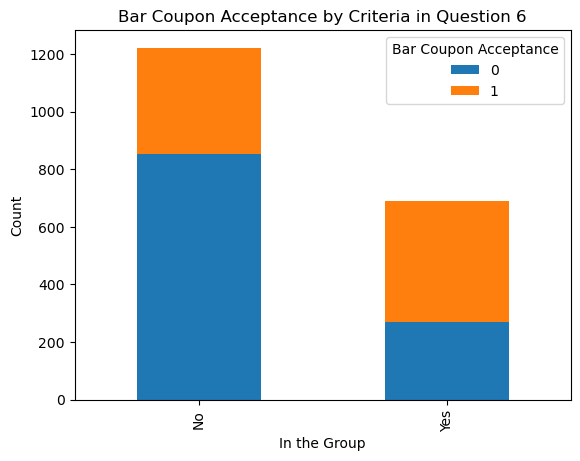

In [42]:
## Bar chart to visualize the acceptance rate by bar_group6
df_bar_coupon.groupby(['bar_group6', 'Y']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Bar Coupon Acceptance by Criteria in Question 6")
plt.xlabel("In the Group")
plt.ylabel("Count")
plt.legend(title="Bar Coupon Acceptance", loc="upper right")
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

- Participants who claim to visit bar regularly are more likely to accept the bar coupon, and those who visit more often and above 25 (possibly more stable/flexible financially) are even more likely to accept the bar coupon
- Participants who have kid(s) as passenger are less likely to accept the coupon
- Participants with lower income and regularly go to cheaper restaurants are less likely to accept the bar coupon

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Coffee Coupons

In [ ]:
## Create new dataframe for coffee house coupon
df_coffee_coupon = cleaned_data[cleaned_data["coupon"] == "Coffee House"].copy()
df_coffee_coupon.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3816 entries, 23 to 12681
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           3816 non-null   object
 1   passenger             3816 non-null   object
 2   weather               3816 non-null   object
 3   temperature           3816 non-null   int64 
 4   time                  3816 non-null   object
 5   coupon                3816 non-null   object
 6   expiration            3816 non-null   object
 7   gender                3816 non-null   object
 8   age                   3816 non-null   object
 9   maritalStatus         3816 non-null   object
 10  has_children          3816 non-null   int64 
 11  education             3816 non-null   object
 12  occupation            3816 non-null   object
 13  income                3816 non-null   object
 14  Bar                   3816 non-null   object
 15  CoffeeHouse           3816 non-null   obj

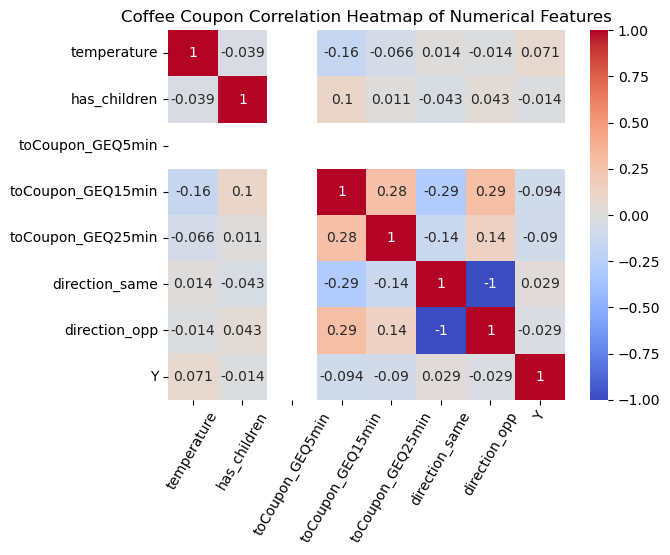

In [49]:
## Heatmap to visualize the correlation between numeric features in coffee coupon dataset
sns.heatmap(df_coffee_coupon[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Coffee Coupon Correlation Heatmap of Numerical Features")
plt.xticks(rotation=60)
plt.savefig("images/coffee_coupon_correlation_heatmap.png")
plt.show()

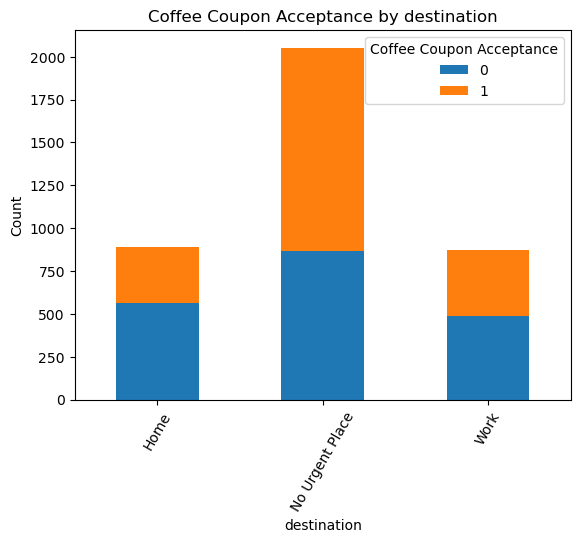

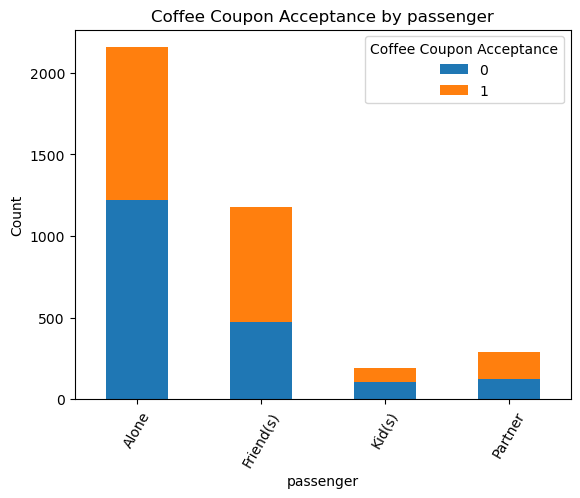

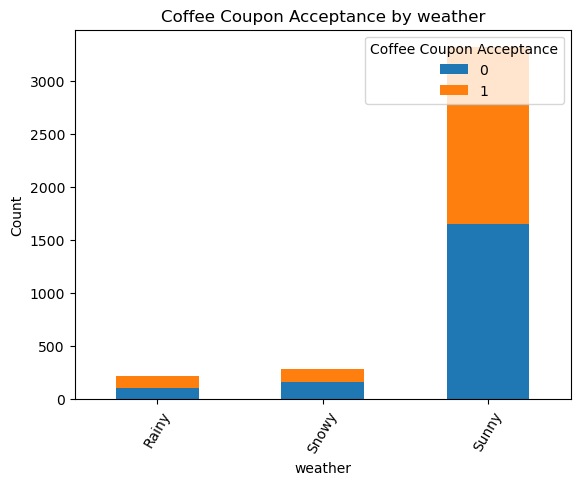

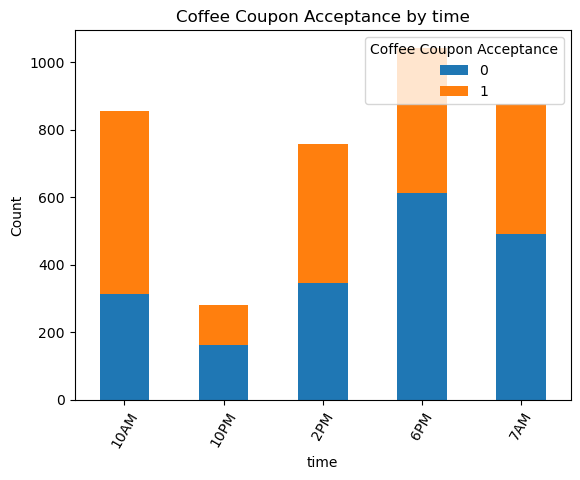

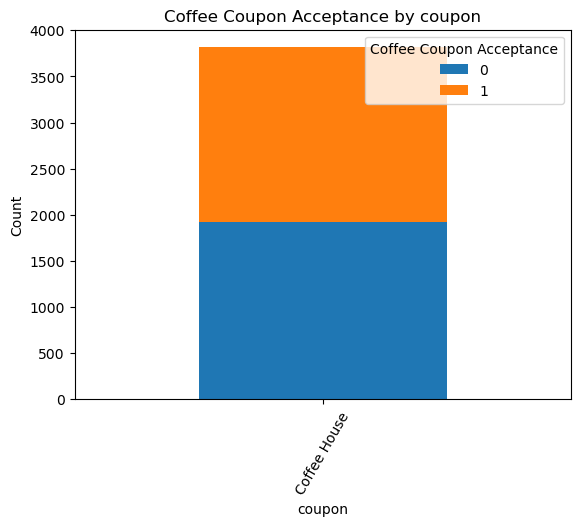

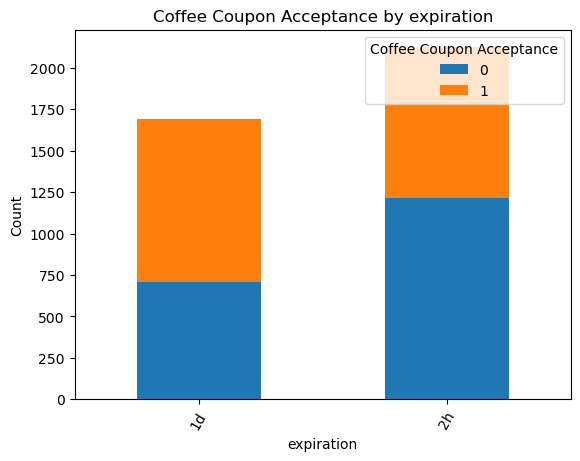

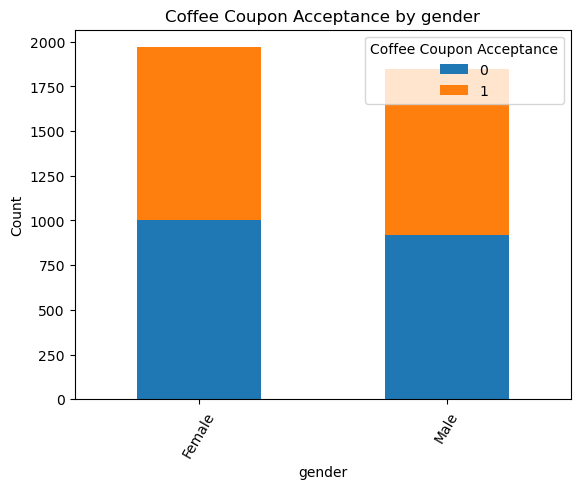

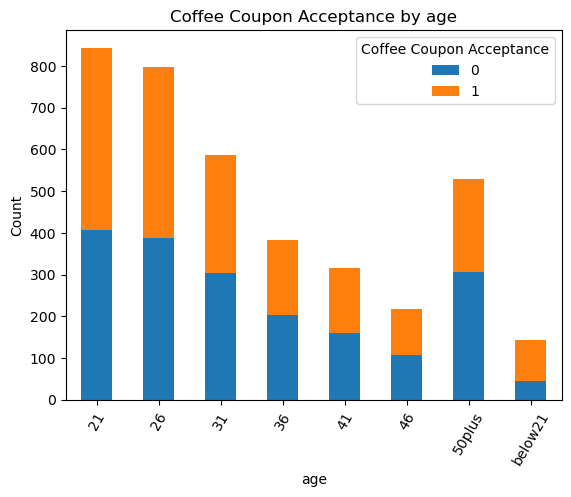

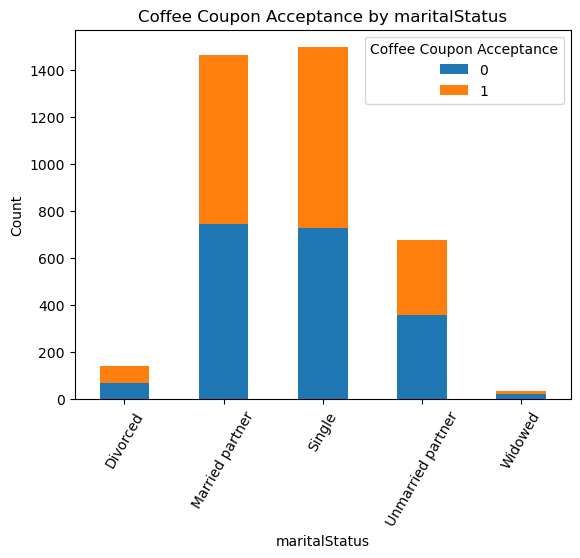

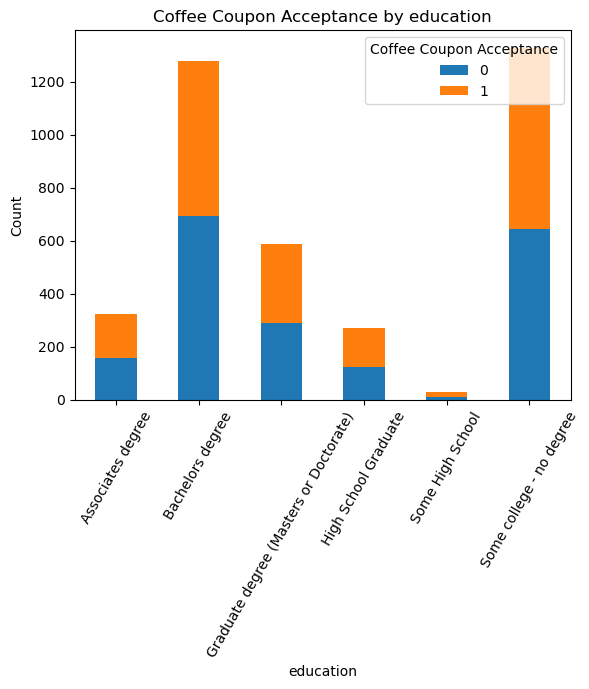

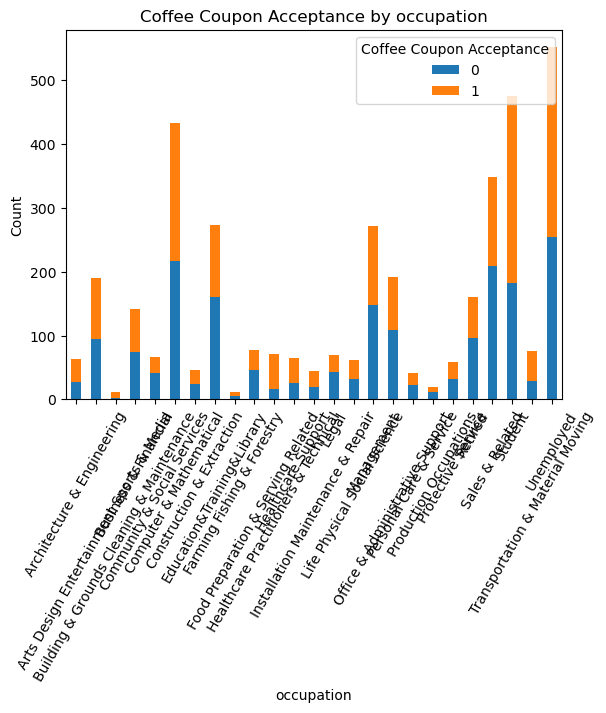

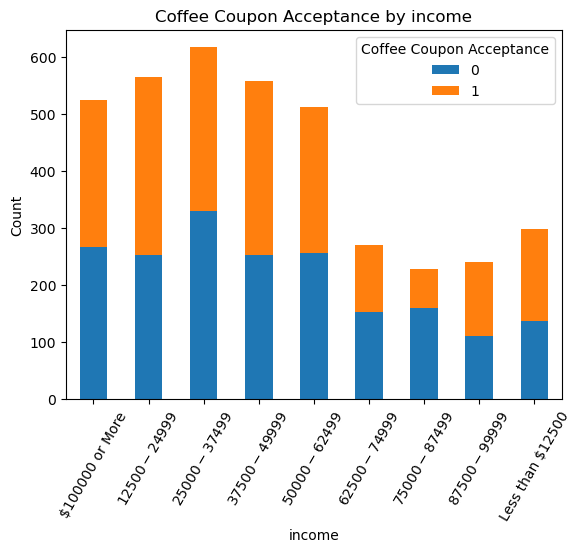

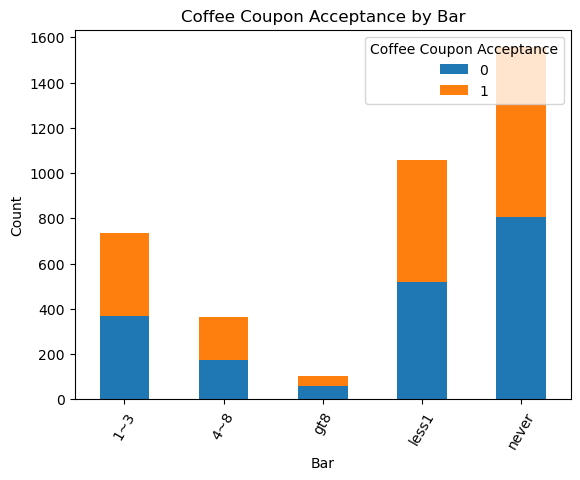

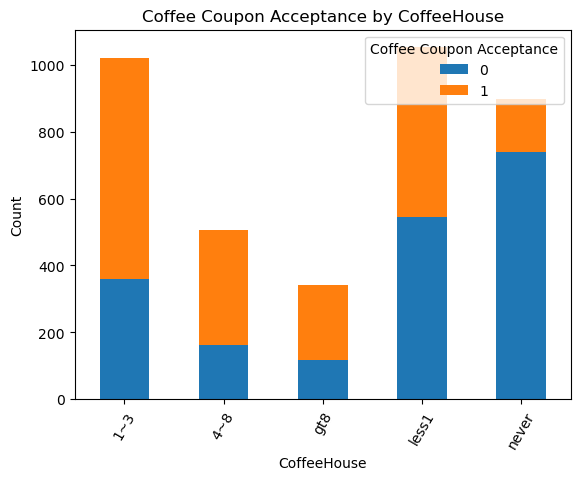

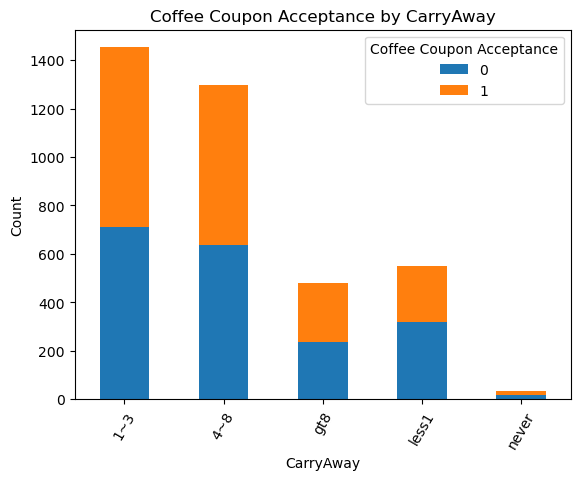

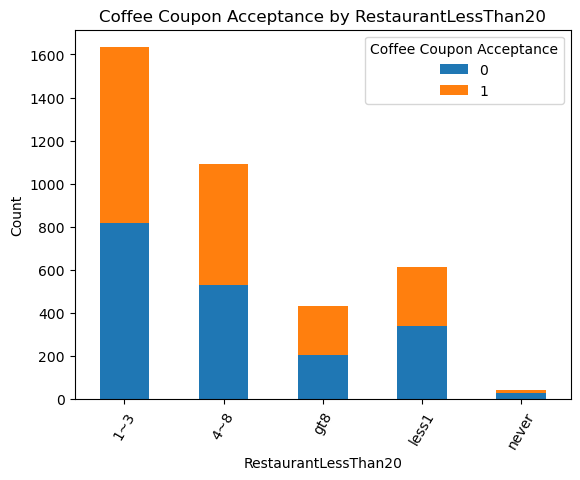

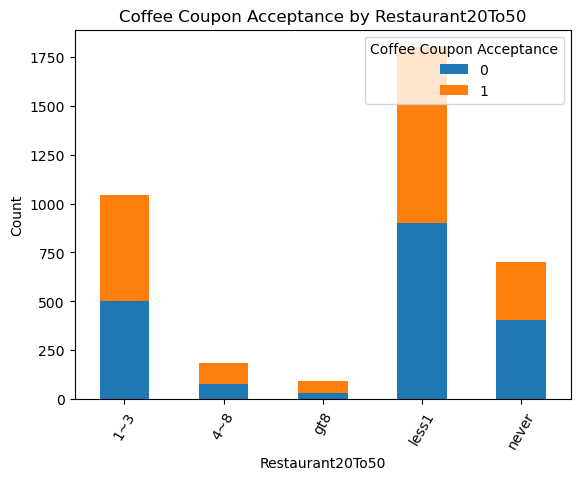

In [ ]:
## To have a quick view of how each categorical feature affects the acceptance rate to help narrow down the focus
## Bar charts to visualize the acceptance rate by categorical features in coffee coupon dataset
for col in categorical_cols:
    df_coffee_coupon.groupby([col, 'Y']).size().unstack().plot(kind='bar', stacked=True)
    plt.title(f"Coffee Coupon Acceptance by {col}")
    plt.xticks(rotation=60)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Coffee Coupon Acceptance", loc="upper right")
    plt.savefig(f"images/coffee_acceptance_by_{col}.png")
    plt.show()

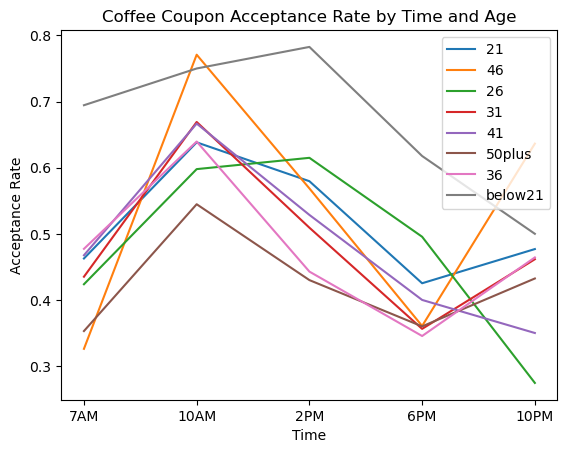

In [74]:
## Check how time impacts the acceptance rate for coffee house coupon
time_order = ['7AM', '10AM', '2PM', '6PM', '10PM']
#plt.plot(df_coffee_coupon.groupby(['time'])['Y'].mean().reindex(time_order))

for age in df_coffee_coupon['age'].unique():
    subset = df_coffee_coupon[df_coffee_coupon['age'] == age]
    plt.plot(subset.groupby(['time'])['Y'].mean().reindex(time_order), label=age)

plt.legend()
plt.title("Coffee Coupon Acceptance Rate by Time and Age")
plt.ylabel("Acceptance Rate")
plt.xlabel("Time")
plt.show()

In [81]:
## Check how occupation impacts the acceptance rate for coffee house coupon
df_coffee_by_occupation = df_coffee_coupon.groupby(['occupation'])['Y'].mean().sort_values()
df_coffee_by_occupation

occupation
Legal                                        0.376812
Community & Social Services                  0.378788
Sales & Related                              0.399425
Food Preparation & Serving Related           0.402597
Retired                                      0.403727
Education&Training&Library                   0.413919
Office & Administrative Support              0.437500
Protective Service                           0.448276
Production Occupations                       0.450000
Management                                   0.453875
Business & Financial                         0.471831
Life Physical Social Science                 0.475410
Personal Care & Service                      0.476190
Construction & Extraction                    0.478261
Arts Design Entertainment Sports & Media     0.500000
Computer & Mathematical                      0.501155
Unemployed                                   0.537205
Farming Fishing & Forestry                   0.545455
Architecture & En

In [88]:
df_coffee_coupon.groupby(['gender'])['Y'].mean().sort_values()

gender
Female    0.491112
Male      0.501895
Name: Y, dtype: float64

In [83]:
## Further how occupation & gender impact the acceptance rate for coffee house coupon
df_coffee_by_occupation_gender = df_coffee_coupon.groupby(['occupation', 'gender'])['Y'].mean().sort_values().unstack()
df_coffee_by_occupation_gender

gender,Female,Male
occupation,,
Architecture & Engineering,0.857143,0.517857
Arts Design Entertainment Sports & Media,0.484076,0.575758
Building & Grounds Cleaning & Maintenance,NaN,0.727273
Business & Financial,0.517241,0.440476
Community & Social Services,0.477273,0.181818
Computer & Mathematical,0.466216,0.519298
Construction & Extraction,0.846154,0.333333
Education&Training&Library,0.439759,0.373832
Farming Fishing & Forestry,NaN,0.545455


In [87]:
df_coffee_by_occupation_gender_joined = pd.merge(df_coffee_by_occupation_gender, df_coffee_by_occupation, on="occupation", how="left")
df_coffee_by_occupation_gender_joined.rename(columns={'Y': 'Overall'}, inplace=True)
df_coffee_by_occupation_gender_joined['female_var'] = df_coffee_by_occupation_gender_joined['Female'] - df_coffee_by_occupation_gender_joined['Overall']
df_coffee_by_occupation_gender_joined['male_var'] = df_coffee_by_occupation_gender_joined['Male'] - df_coffee_by_occupation_gender_joined['Overall']
df_coffee_by_occupation_gender_joined['gender_var'] = df_coffee_by_occupation_gender_joined['Female'] - df_coffee_by_occupation_gender_joined['Male']
df_coffee_by_occupation_gender_joined

,Female,Male,Overall,female_var,male_var,gender_var
occupation,,,,,,
Architecture & Engineering,0.857143,0.517857,0.555556,0.301587,-0.037698,0.339286
Arts Design Entertainment Sports & Media,0.484076,0.575758,0.500000,-0.015924,0.075758,-0.091681
Building & Grounds Cleaning & Maintenance,NaN,0.727273,0.727273,NaN,0.000000,NaN
Business & Financial,0.517241,0.440476,0.471831,0.045410,-0.031355,0.076765
Community & Social Services,0.477273,0.181818,0.378788,0.098485,-0.196970,0.295455
Computer & Mathematical,0.466216,0.519298,0.501155,-0.034939,0.018144,-0.053082
Construction & Extraction,0.846154,0.333333,0.478261,0.367893,-0.144928,0.512821
Education&Training&Library,0.439759,0.373832,0.413919,0.025840,-0.040088,0.065927
Farming Fishing & Forestry,NaN,0.545455,0.545455,NaN,0.000000,NaN


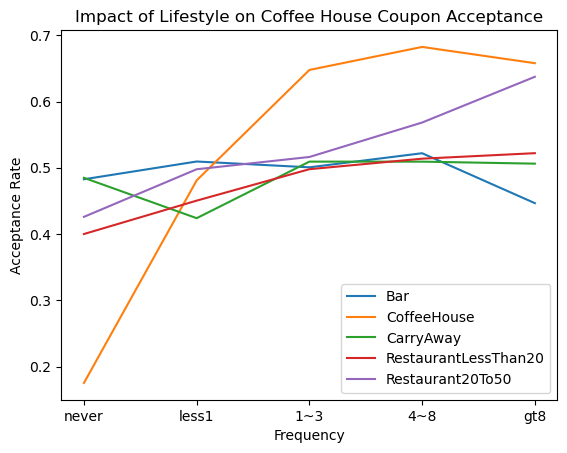

In [99]:
## Check how lifestyle impacts the acceptance rate for coffee house coupon
fre_order = ['never', 'less1', '1~3', '4~8', 'gt8']
for col in ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']:
    plt.plot(df_coffee_coupon.groupby([col])['Y'].mean().reindex(fre_order), label=col)
plt.legend()
plt.xlabel('Frequency')
plt.ylabel('Acceptance Rate')
plt.title('Impact of Lifestyle on Coffee House Coupon Acceptance')
plt.show()

In [ ]:
## Take a closer look at the impact of regular coffee house visits on the acceptance rate for coffee house coupon
df_coffee_coupon.groupby(['CoffeeHouse'])['Y'].mean().sort_values()

CoffeeHouse
never    0.175223
less1    0.480989
1~3      0.647694
gt8      0.657895
4~8      0.682446
Name: Y, dtype: float64

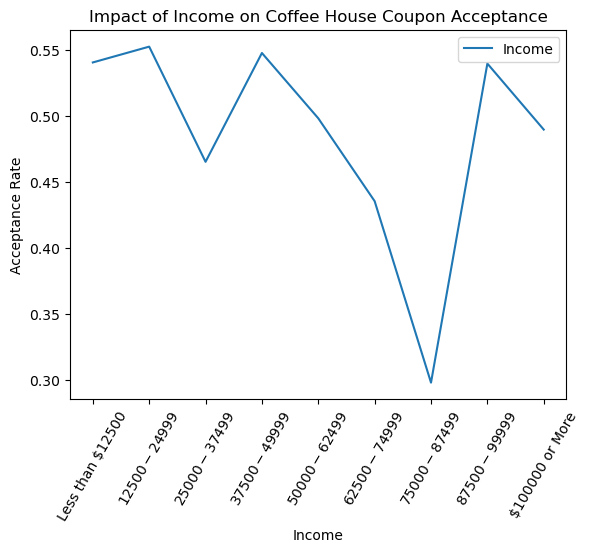

In [102]:
## Check how income impacts the acceptance rate for coffee house coupon
income_order = [
    'Less than $12500',
    '$12500 - $24999',
    '$25000 - $37499',
    '$37500 - $49999',
    '$50000 - $62499',
    '$62500 - $74999',
    '$75000 - $87499',
    '$87500 - $99999',
    '$100000 or More'
]

plt.plot(df_coffee_coupon.groupby(['income'])['Y'].mean().reindex(income_order), label='Income')
plt.legend()
plt.xlabel('Income')
plt.xticks(rotation=60)
plt.ylabel('Acceptance Rate')
plt.title('Impact of Income on Coffee House Coupon Acceptance')
plt.show()

### Other Investigations

Data explorer 

In [69]:
cleaned_data.groupby(['coupon'])['Y'].mean()

coupon
Bar                      0.411918
Carry out & Take away    0.737719
Coffee House             0.496331
Restaurant(20-50)        0.446013
Restaurant(<20)          0.709009
Name: Y, dtype: float64

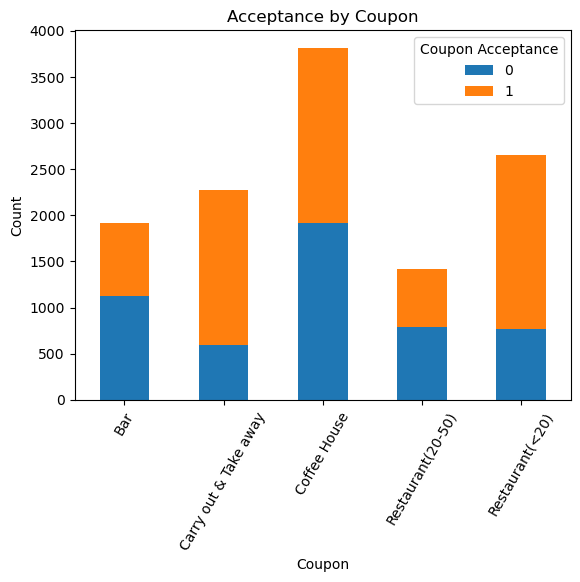

In [29]:
cleaned_data.groupby(['coupon', 'Y']).size().unstack().plot(kind='bar', stacked=True)
plt.title("Acceptance by Coupon")
plt.xticks(rotation=60)
plt.xlabel("Coupon")
plt.ylabel("Count")
plt.legend(title="Coupon Acceptance", loc="upper right")

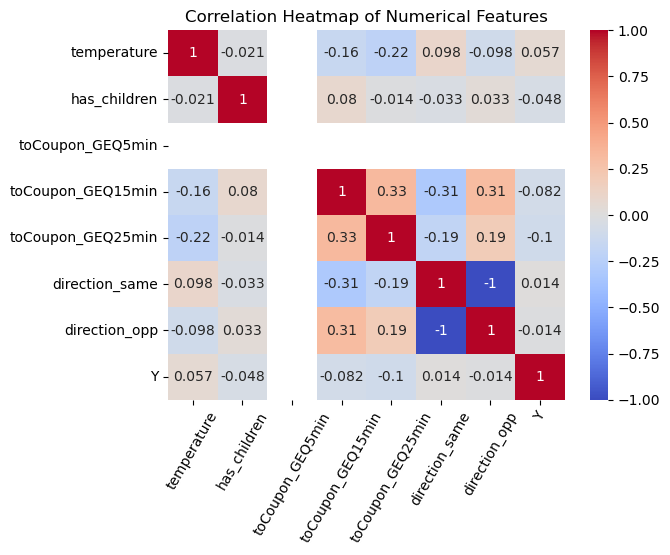

In [32]:
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.xticks(rotation=60)
plt.savefig("images/correlation_heatmap.png")
plt.show()

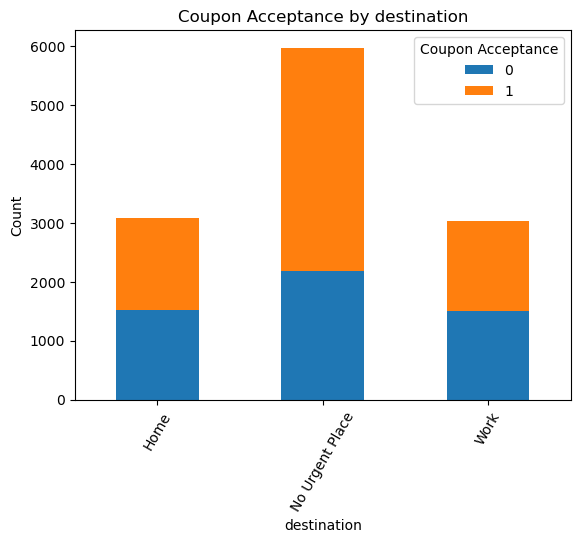

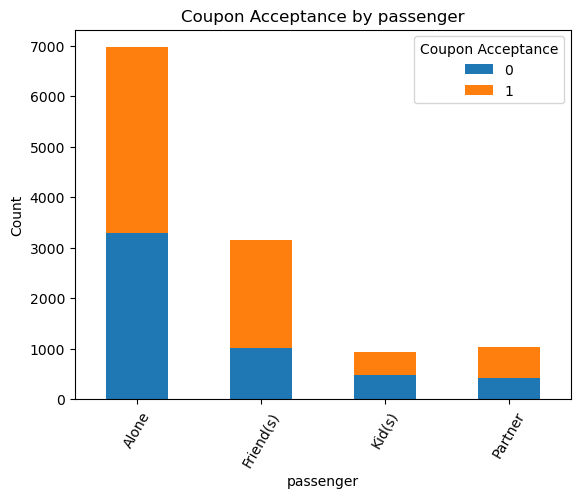

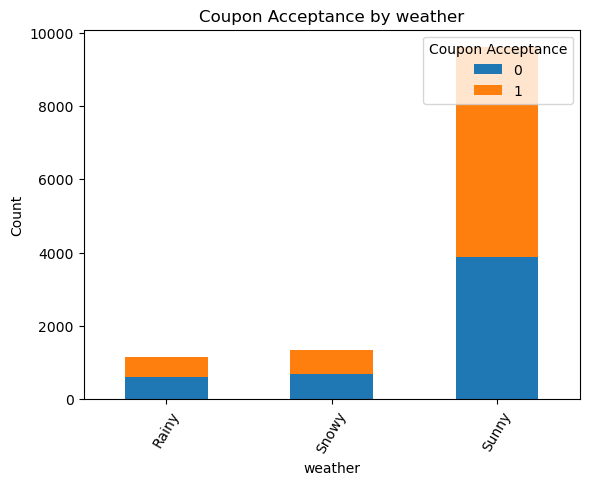

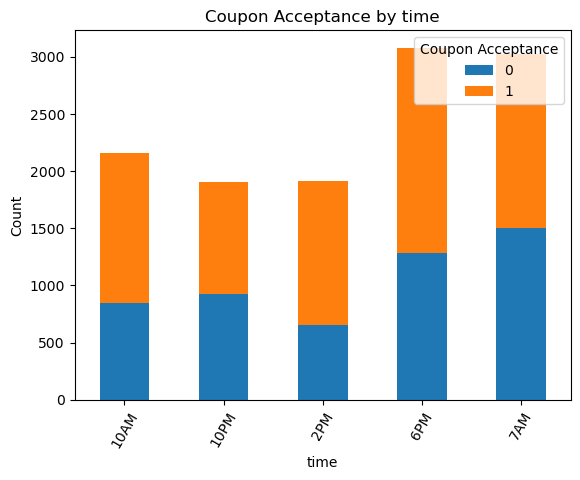

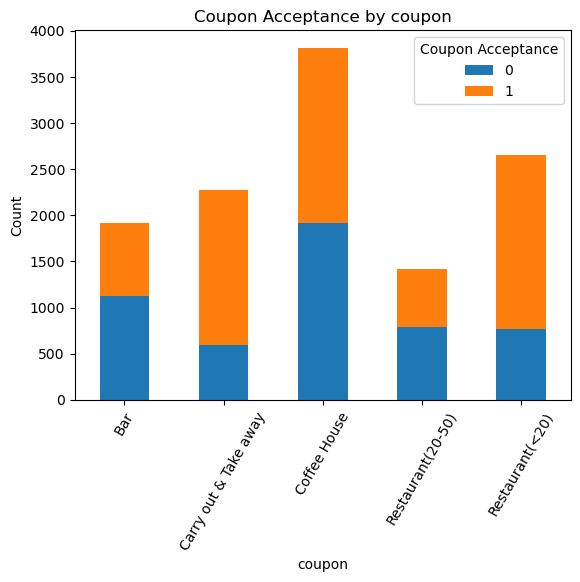

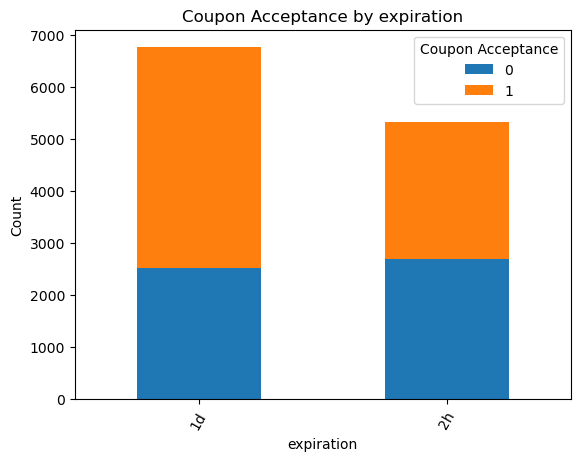

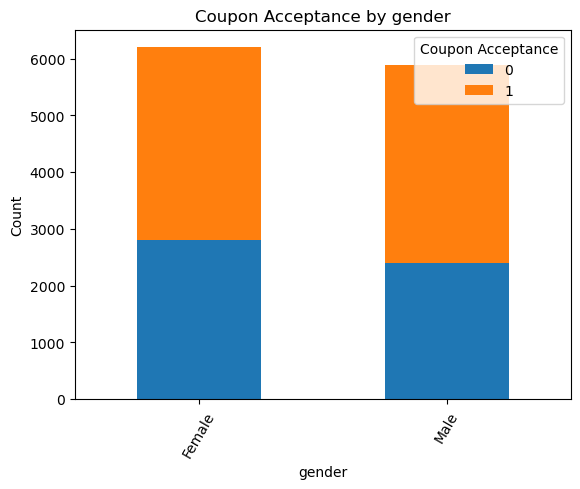

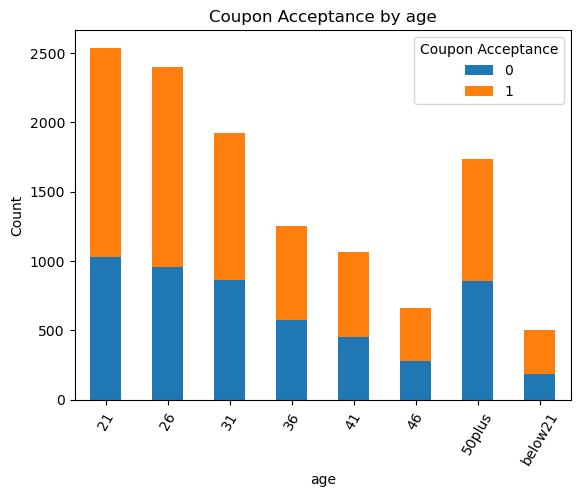

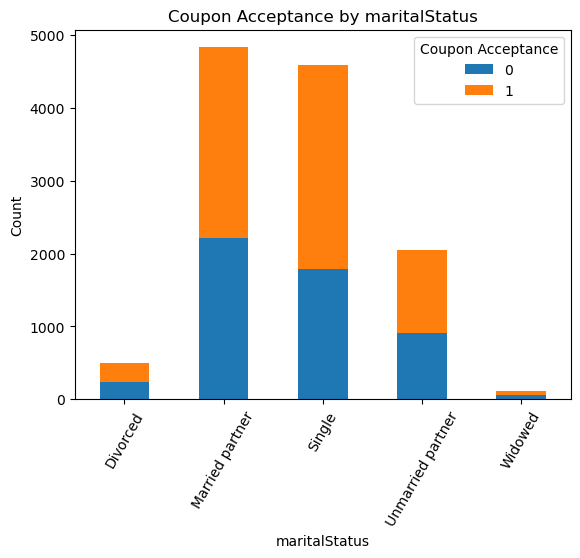

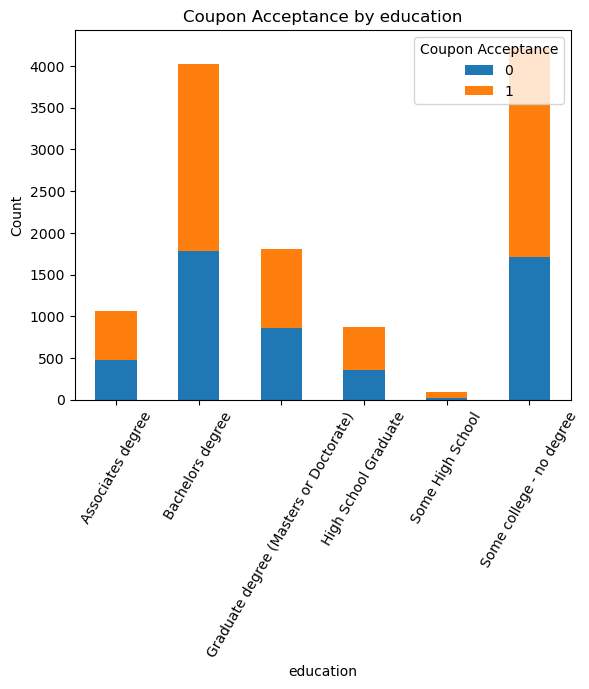

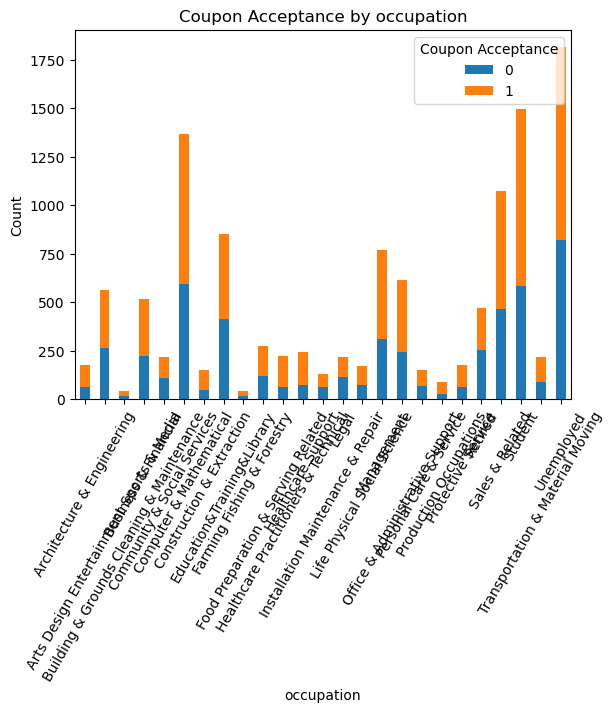

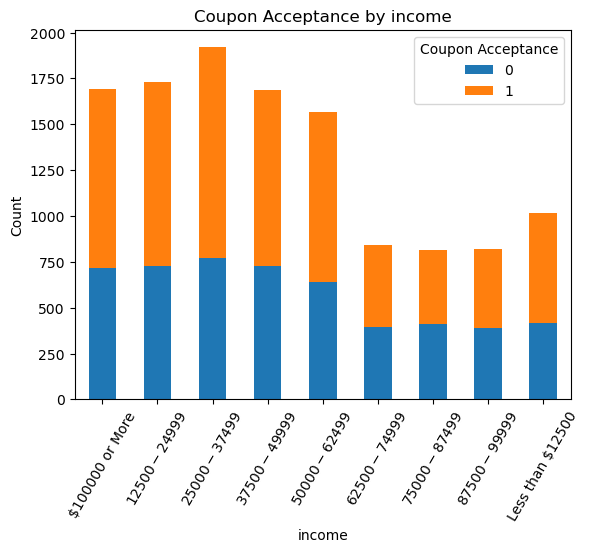

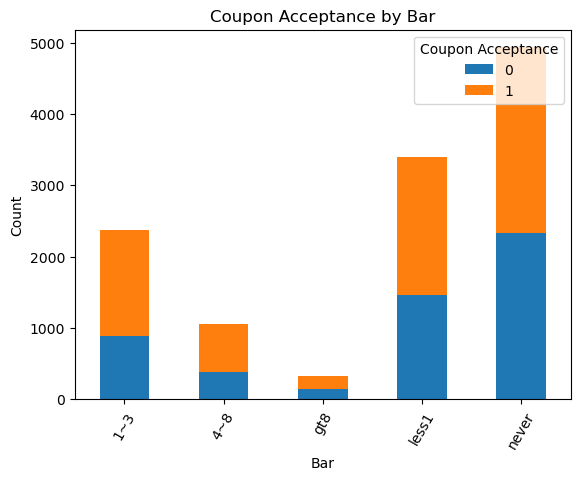

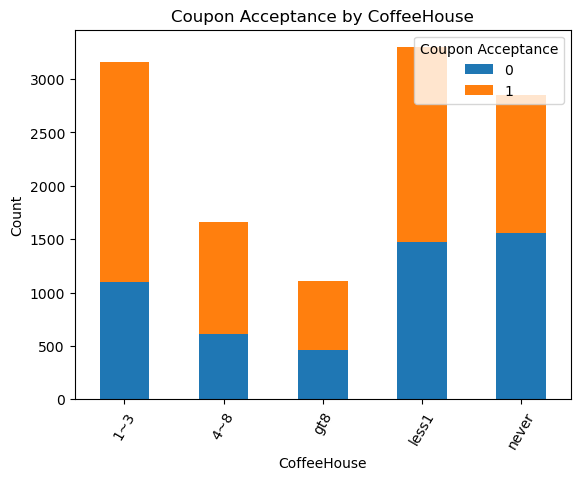

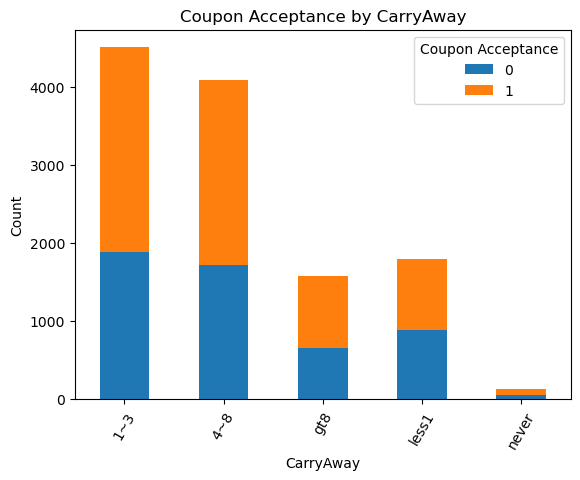

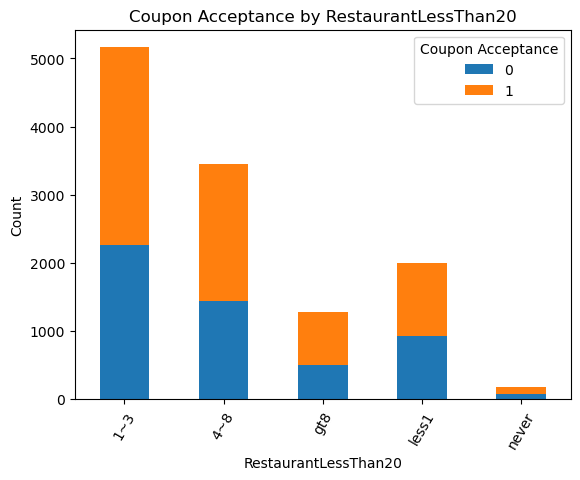

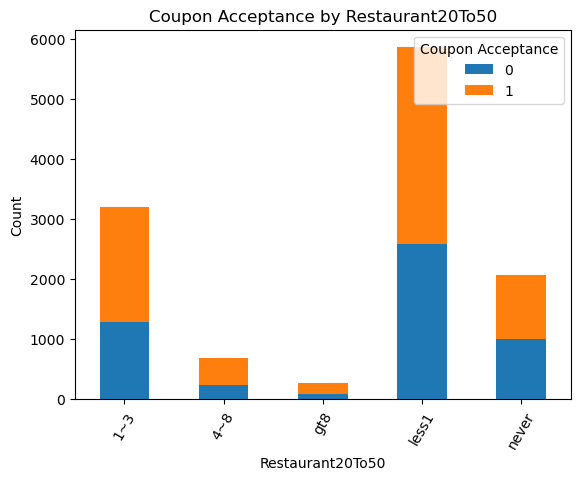

In [33]:
for col in categorical_cols:
    cleaned_data.groupby([col, 'Y']).size().unstack().plot(kind='bar', stacked=True)
    plt.title(f"Coupon Acceptance by {col}")
    plt.xticks(rotation=60)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Coupon Acceptance", loc="upper right")
    #plt.savefig(f"images/bar_{col}.png")
    plt.show()